#**PROBLEMA DE NEGOCIO**


---


Una agencia inmobiliaria en California necesita mejorar su estrategia de precios para optimizar la compra y venta de propiedades. Actualmente, no se están considerando adecuadamente las variables espaciales, como la distancia a la costa y la proximidad a ciudades importantes, lo que afecta la rentabilidad. El objetivo del proyecto es desarrollar un modelo predictivo que, usando datos de geolocalización (latitud, longitud, distancia a la costa) y características del inmueble, permita estimar con precisión el precio de las viviendas y mejorar la toma de decisiones en su estrategia de precios.

### **Tus tareas principales serán:**

**1. Exploración de Datos:** Analizar y comprender el conjunto de datos proporcionado, identificar variables clave y realizar visualizaciones para entender las relaciones entre las variables y seleccionar las características relevantes. Identificar tambien si la posicion geografica es determinante en el precio.

**2. Preprocesamiento de Datos:** Realizar limpieza de datos, limpiar valores atipicos y normalización/escalado de datos.

**3. Construcción de Modelos:** Experimentar con algunos algoritmos de machine learning xgboost para predecir el valor medio de las viviendas.

**4. Evaluación y Selección del Modelo:**  Determinar el ajuste optimo del modelo por medio de `GridSearchCV` para tener predicciones que puedan ser empleadas como una herramienta de valorizacion de esos predios.

#**1. Configuración del Ambiente**


---

In [125]:
import h3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
from folium.plugins import HeatMap
from IPython.display import display
import branca.colormap as cm
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


#**2. Exploración de Datos**


---

In [2]:
# Cargar dataset desde un archivo CSV (ajusta la ruta a tu archivo)
data = pd.read_csv('California_Houses.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Median_House_Value        20640 non-null  float64
 1   Median_Income             20640 non-null  float64
 2   Median_Age                20640 non-null  int64  
 3   Tot_Rooms                 20640 non-null  int64  
 4   Tot_Bedrooms              20640 non-null  int64  
 5   Population                20640 non-null  int64  
 6   Households                20640 non-null  int64  
 7   Latitude                  20640 non-null  float64
 8   Longitude                 20640 non-null  float64
 9   Distance_to_coast         20640 non-null  float64
 10  Distance_to_LA            20640 non-null  float64
 11  Distance_to_SanDiego      20640 non-null  float64
 12  Distance_to_SanJose       20640 non-null  float64
 13  Distance_to_SanFrancisco  20640 non-null  float64
dtypes: flo

In [3]:
data.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
0,452600.0,8.3252,41,880,129,322,126,37.88,-122.23,9263.040773,556529.158342,735501.806984,67432.517001,21250.213767
1,358500.0,8.3014,21,7099,1106,2401,1138,37.86,-122.22,10225.733072,554279.850069,733236.884360,65049.908574,20880.600400
2,352100.0,7.2574,52,1467,190,496,177,37.85,-122.24,8259.085109,554610.717069,733525.682937,64867.289833,18811.487450
3,341300.0,5.6431,52,1274,235,558,219,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
4,342200.0,3.8462,52,1627,280,565,259,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568


In [4]:
data.describe()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,2.064000e+04,2.064000e+04,20640.000000,20640.000000
mean,206855.816909,3.870671,28.639486,2635.763081,537.898014,1425.476744,499.539680,35.631861,-119.569704,40509.264883,2.694220e+05,3.981649e+05,349187.551219,386688.422291
std,115395.615874,1.899822,12.585558,2181.615252,421.247906,1132.462122,382.329753,2.135952,2.003532,49140.039160,2.477324e+05,2.894006e+05,217149.875026,250122.192316
min,14999.000000,0.499900,1.000000,2.000000,1.000000,3.000000,1.000000,32.540000,-124.350000,120.676447,4.205891e+02,4.849180e+02,569.448118,456.141313
25%,119600.000000,2.563400,18.000000,1447.750000,295.000000,787.000000,280.000000,33.930000,-121.800000,9079.756762,3.211125e+04,1.594264e+05,113119.928682,117395.477505
50%,179700.000000,3.534800,29.000000,2127.000000,435.000000,1166.000000,409.000000,34.260000,-118.490000,20522.019101,1.736675e+05,2.147398e+05,459758.877000,526546.661701
75%,264725.000000,4.743250,37.000000,3148.000000,647.000000,1725.000000,605.000000,37.710000,-118.010000,49830.414479,5.271562e+05,7.057954e+05,516946.490963,584552.007907
max,500001.000000,15.000100,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,41.950000,-114.310000,333804.686371,1.018260e+06,1.196919e+06,836762.678210,903627.663298


In [5]:
print(data.isnull().sum())

Median_House_Value          0
Median_Income               0
Median_Age                  0
Tot_Rooms                   0
Tot_Bedrooms                0
Population                  0
Households                  0
Latitude                    0
Longitude                   0
Distance_to_coast           0
Distance_to_LA              0
Distance_to_SanDiego        0
Distance_to_SanJose         0
Distance_to_SanFrancisco    0
dtype: int64


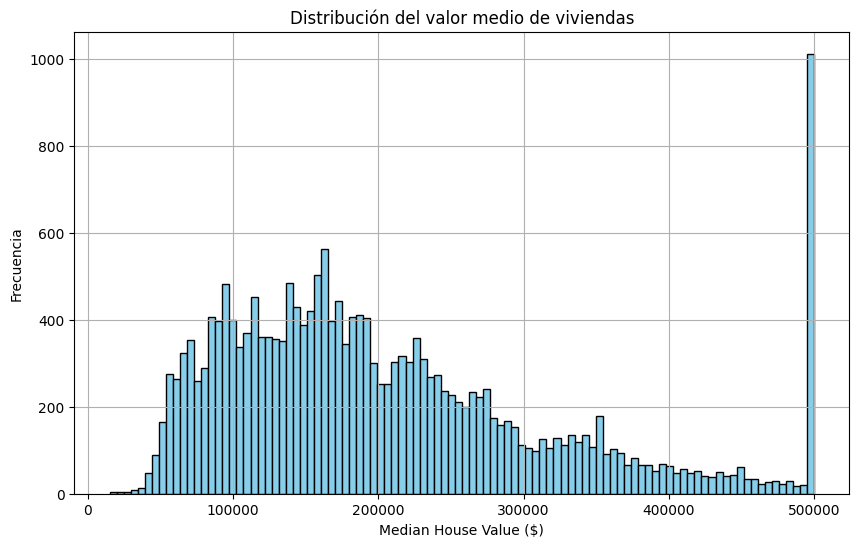

In [6]:
# En el siguiente grafico se mira que el precio de vivienda en el eje X y en el eje Y la cantidad de casas a ese precio. En 120000 y 140000 se concentra la mayor cantidad
plt.figure(figsize=(10, 6))

data["Median_House_Value"].hist(bins=100, color='skyblue', edgecolor='black')
plt.title("Distribución del valor medio de viviendas")
plt.xlabel("Median House Value ($)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

# tenemos un histograma con sesgo a la derecha 100 intervalos

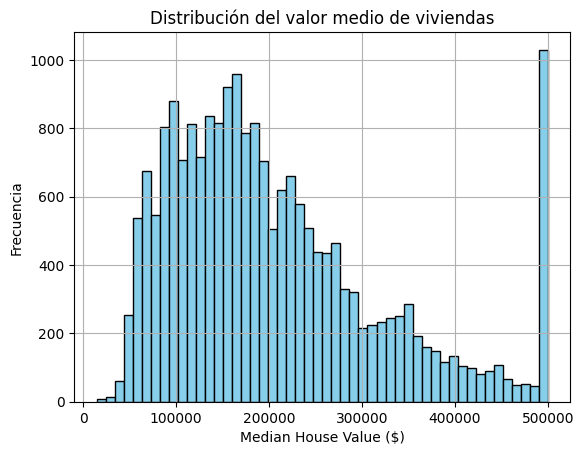

In [7]:
data["Median_House_Value"].hist(bins=50, color='skyblue', edgecolor='black')
plt.title("Distribución del valor medio de viviendas")
plt.xlabel("Median House Value ($)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()


# tenemos un histograma con sesgo a la derecha 50 intervalos 

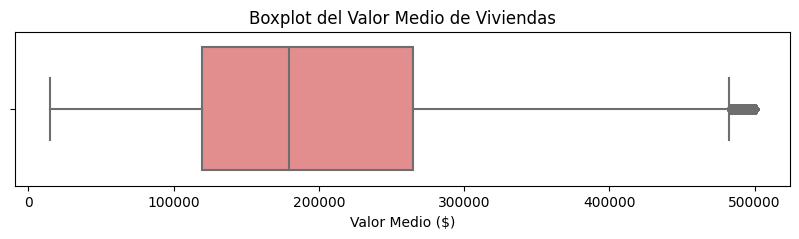

In [8]:
import seaborn as sns

plt.figure(figsize=(10, 2))
sns.boxplot(x=data['Median_House_Value'], color='lightcoral')
plt.title('Boxplot del Valor Medio de Viviendas')
plt.xlabel('Valor Medio ($)')
plt.show()

# Observamos que tenemos outliers

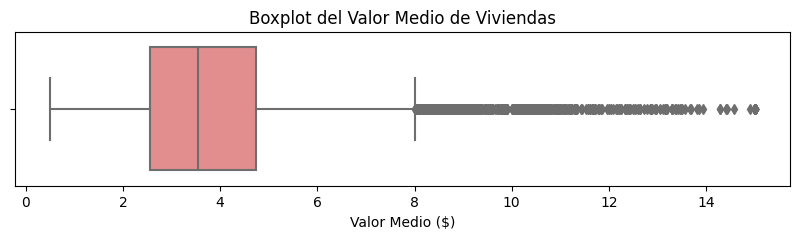

In [9]:
import seaborn as sns

plt.figure(figsize=(10, 2))
sns.boxplot(x=data['Median_Income'], color='lightcoral')
plt.title('Boxplot del Valor Medio de Viviendas')
plt.xlabel('Valor Medio ($)')
plt.show()


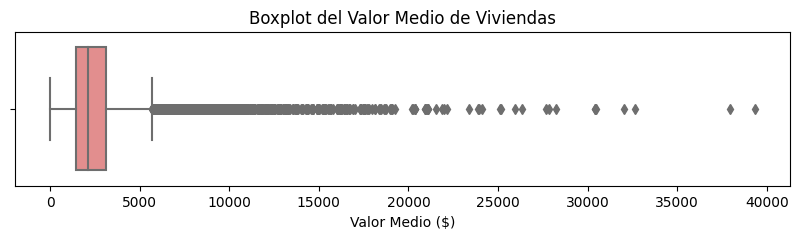

In [10]:
import seaborn as sns

plt.figure(figsize=(10, 2))
sns.boxplot(x=data['Tot_Rooms'], color='lightcoral')
plt.title('Boxplot del Valor Medio de Viviendas')
plt.xlabel('Valor Medio ($)')
plt.show()


In [11]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn', 'seaborn-bright', 'seaborn-colorblind', 'seaborn-dark', 'seaborn-dark-palette', 'seaborn-darkgrid', 'seaborn-deep', 'seaborn-muted', 'seaborn-notebook', 'seaborn-paper', 'seaborn-pastel', 'seaborn-poster', 'seaborn-talk', 'seaborn-ticks', 'seaborn-white', 'seaborn-whitegrid', 'tableau-colorblind10']


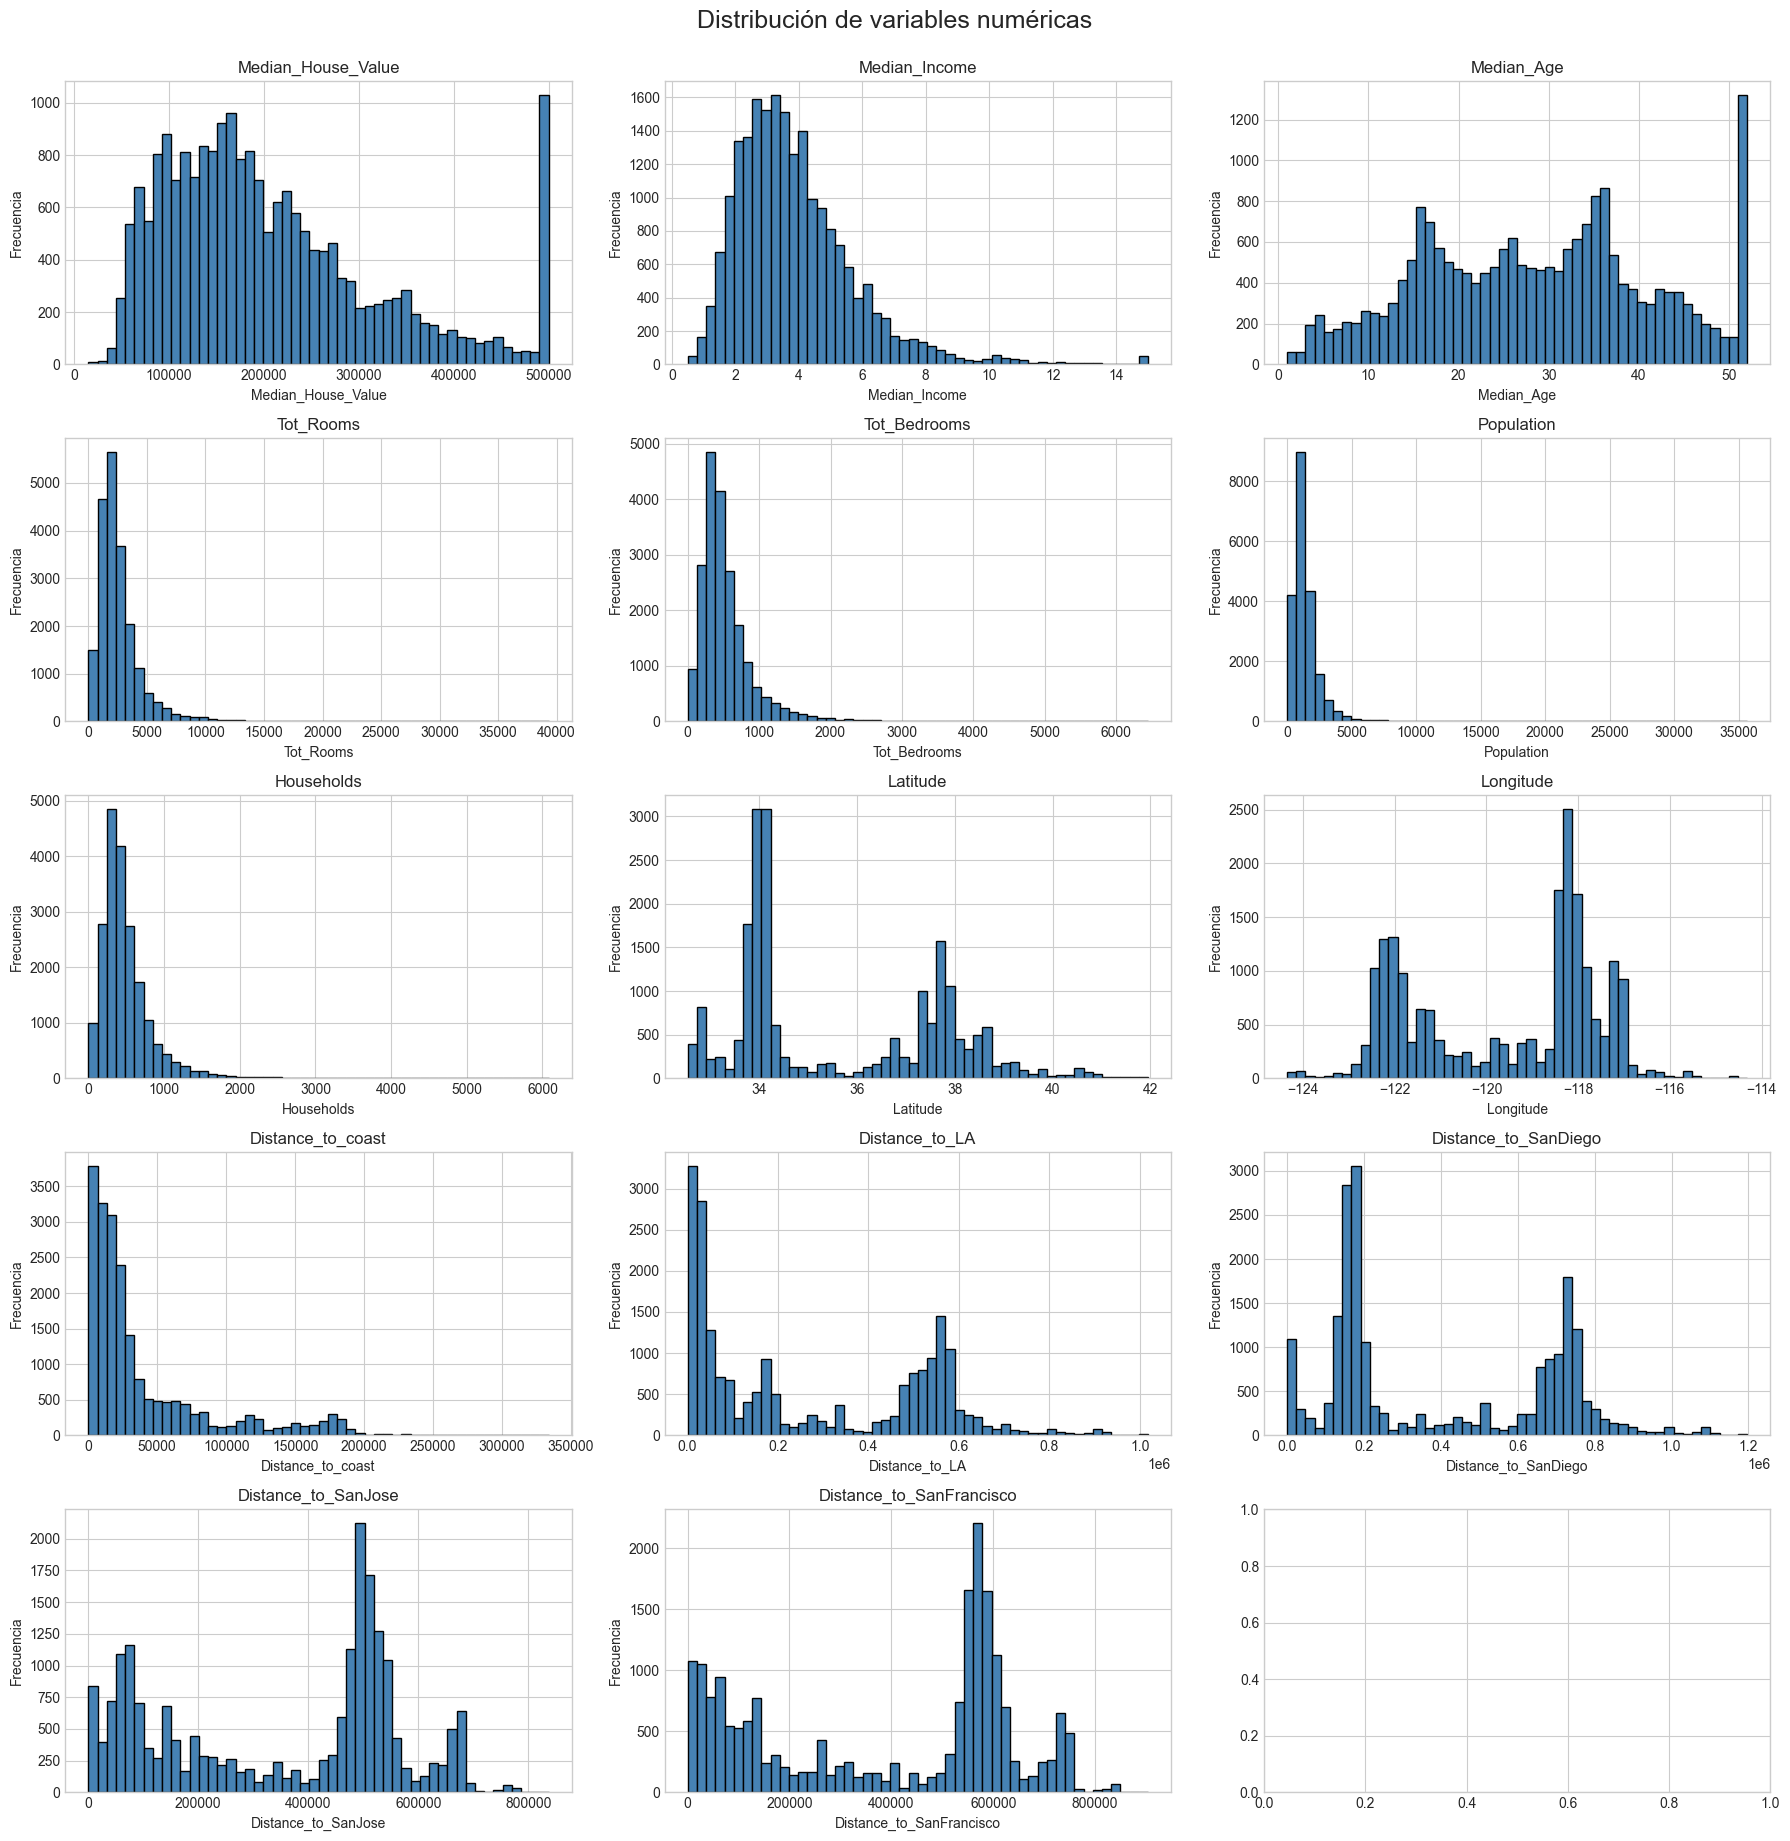

In [12]:
# Establecer estilo
plt.style.use('seaborn-whitegrid')

# Columnas numéricas (todas en tu dataset son numéricas)
columnas = data.select_dtypes(include='number').columns

# Crear los histogramas
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(columnas):
    data[col].hist(bins=50, ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

# Ajustar espacios
plt.tight_layout()
plt.suptitle("Distribución de variables numéricas", fontsize=18, y=1.02)
plt.show()

In [13]:
data_capped = data[data["Median_House_Value"] >= 500000]
pd.reset_option('display.max_rows')
display(data_capped[['Median_House_Value', 'Latitude', 'Longitude', 'Median_Income']])

,Median_House_Value,Latitude,Longitude,Median_Income
89,500001.0,37.80,-122.27,1.2434
459,500001.0,37.87,-122.25,1.1696
493,500001.0,37.86,-122.24,7.8521
494,500001.0,37.85,-122.24,9.3959
509,500001.0,37.83,-122.23,7.8772
...,...,...,...,...
20422,500001.0,34.14,-118.90,5.1457
20426,500001.0,34.18,-118.69,10.0472
20427,500001.0,34.19,-118.80,8.6499
20436,500001.0,34.21,-118.69,12.5420


In [14]:
num_truncadas = data[data["Median_House_Value"] >= 500000].shape[0]
num_truncadas

992

In [15]:
data.shape[0]

20640

<AxesSubplot:xlabel='Longitude', ylabel='Latitude'>

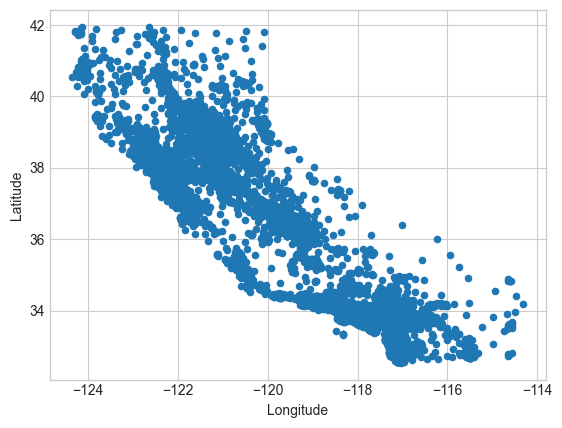

In [16]:
data.plot.scatter(x='Longitude',y='Latitude')

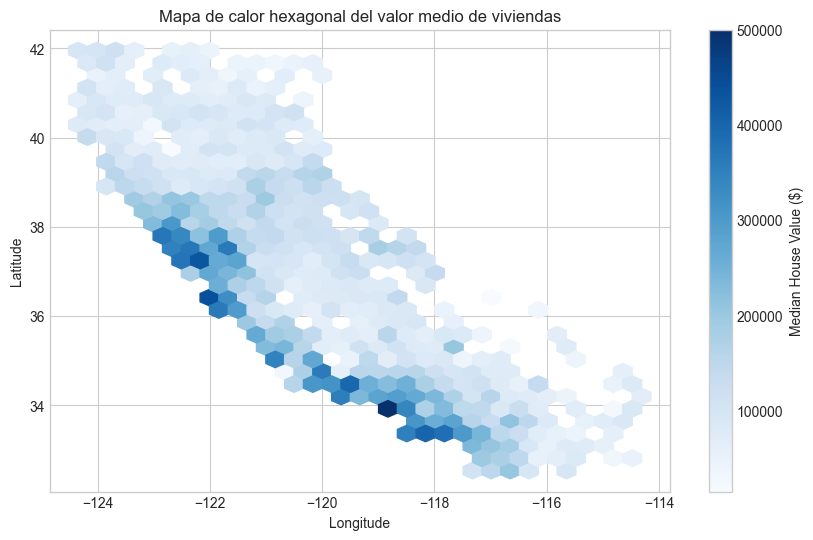

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

hb = ax.hexbin(
    data['Longitude'],
    data['Latitude'],
    C=data['Median_House_Value'],
    reduce_C_function=np.mean,
    gridsize=30,
    cmap='Blues'
)

cb = fig.colorbar(hb, ax=ax)
cb.set_label('Median House Value ($)')

ax.set_title('Mapa de calor hexagonal del valor medio de viviendas')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()


#En la costa se observa que tienen mayor valor medio en precios

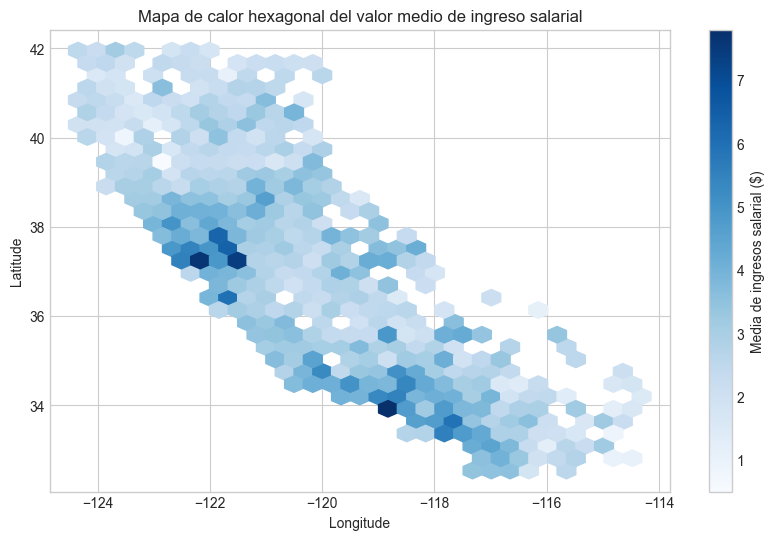

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

hb = ax.hexbin(
    data['Longitude'],
    data['Latitude'],
    C=data['Median_Income'],
    reduce_C_function=np.mean,
    gridsize=30,
    cmap='Blues'
)

cb = fig.colorbar(hb, ax=ax)
cb.set_label('Media de ingresos salarial ($)')

ax.set_title('Mapa de calor hexagonal del valor medio de ingreso salarial')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

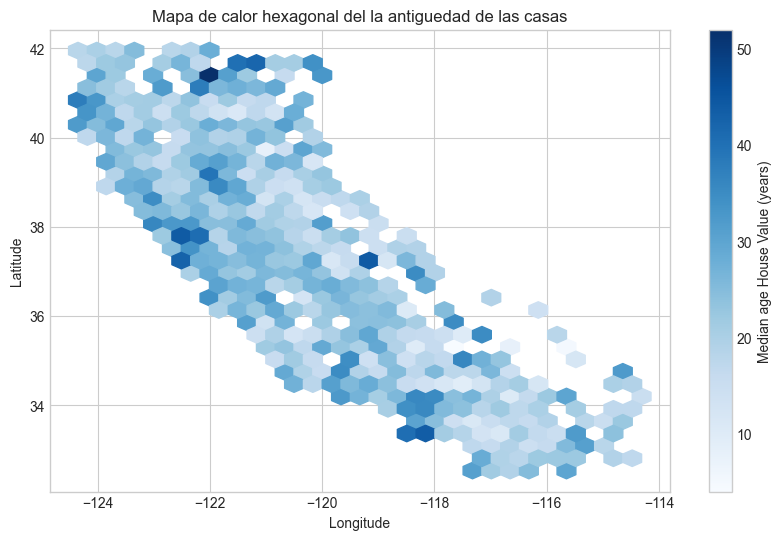

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

hb = ax.hexbin(
    data['Longitude'],
    data['Latitude'],
    C=data['Median_Age'],
    reduce_C_function=np.mean,
    gridsize=30,
    cmap='Blues'
)

cb = fig.colorbar(hb, ax=ax)
cb.set_label('Median age House Value (years)')

ax.set_title('Mapa de calor hexagonal del la antiguedad de las casas')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

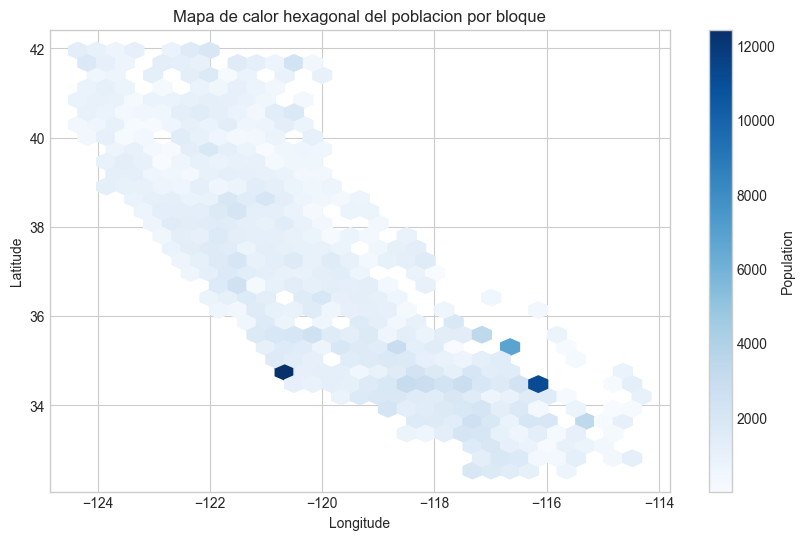

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

hb = ax.hexbin(
    data['Longitude'],
    data['Latitude'],
    C=data['Population'],
    reduce_C_function=np.mean,
    gridsize=30,
    cmap='Blues'
)

cb = fig.colorbar(hb, ax=ax)
cb.set_label('Population')

ax.set_title('Mapa de calor hexagonal del poblacion por bloque')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

# Las personas se estan concentrando en ciertas zonas.

In [21]:
mapa = folium.Map(location=[36.7783, -119.4179], zoom_start=6)
marker_cluster = MarkerCluster().add_to(mapa)

# Agregar los marcadores
for i, row in data.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Index: {i}"
    ).add_to(marker_cluster)

# Guardar el mapa como archivo HTML
mapa.save("mapa_interactivo.html")

In [22]:
# Crear el mapa centrado en California
mapa = folium.Map(
    location=[36.7783, -119.4179], 
    zoom_start=6,
    )

# Crear la lista de puntos: [latitud, longitud]
heat_data = data[['Latitude', 'Longitude']].dropna().values.tolist()

# Agregar el HeatMap
HeatMap(heat_data, radius=10).add_to(mapa)

# Mostrar el mapa directamente en el notebook
display(mapa)

In [23]:
print(data.columns)

Index(['Median_House_Value', 'Median_Income', 'Median_Age', 'Tot_Rooms',
       'Tot_Bedrooms', 'Population', 'Households', 'Latitude', 'Longitude',
       'Distance_to_coast', 'Distance_to_LA', 'Distance_to_SanDiego',
       'Distance_to_SanJose', 'Distance_to_SanFrancisco'],
      dtype='object')


In [24]:
import branca.colormap as cm

In [25]:
import branca.colormap as cm

# 1. Función de agregación (sin cambios)
def hexbin_aggregation(data, target_column, resolution=7):
    hex_data = []
    for _, row in data.iterrows():
        try:
            hex_id = h3.geo_to_h3(row['Latitude'], row['Longitude'], resolution)
            hex_data.append({
                'hex_id': hex_id,
                'value': row[target_column],
                'Latitude': row['Latitude'],
                'Longitude': row['Longitude']
            })
        except KeyError as e:
            print(f"Error: Falta columna requerida - {e}")
            return pd.DataFrame()
    
    df_hex = pd.DataFrame(hex_data)
    return df_hex.groupby('hex_id').agg({
        'value': 'mean',
        'Latitude': 'first',
        'Longitude': 'first'
    }).reset_index()

# 2. Cargar datos
data = pd.read_csv("California_houses.csv")  # Asegúrate de la ruta correcta

# 3. Verificar columnas disponibles
print("Columnas disponibles:", data.columns.tolist())

# 4. Configuración del mapa
base_location = [36.7783, -119.4179]
resolutions = {
    "Lejano (zoom 5-7)": 5,
    "Medio (zoom 8-10)": 7, 
    "Cercano (zoom 11+)": 9
}

# 5. Función para crear mapas (modificada para no mostrar en notebook)
def create_hexmap(target_column, title):
    m = folium.Map(location=base_location, zoom_start=6)
    
    colormap = cm.LinearColormap(
        colors=['blue', 'green', 'yellow', 'red'],
        vmin=data[target_column].min(),
        vmax=data[target_column].max(),
        caption=title
    )
    
    for name, res in resolutions.items():
        df_hex = hexbin_aggregation(data, target_column, res)
        
        if df_hex.empty:
            continue
            
        fg = folium.FeatureGroup(name=name, show=(res==7))
        
        for _, row in df_hex.iterrows():
            try:
                hex_vertices = h3.h3_to_geo_boundary(row['hex_id'])
                folium.Polygon(
                    locations=hex_vertices,
                    fill=True,
                    fill_color=colormap(row['value']),
                    fill_opacity=0.7,
                    weight=0.5,
                    color='white',
                    tooltip=f"{title}: {row['value']:.2f}"
                ).add_to(fg)
            except Exception as e:
                print(f"Error procesando hexágono {row['hex_id']}: {e}")
        
        fg.add_to(m)
    
    folium.LayerControl().add_to(m)
    colormap.add_to(m)
    
    # Guardar el mapa como HTML (sin mostrar en notebook)
    output_file = f"hexmap_{target_column.lower()}.html"
    m.save(output_file)
    print(f"Mapa guardado como: {output_file}")

# 6. Generar mapas para cada variable (sin display())
variables = {
    'Median_Income': "Ingreso Medio ($)",
    'Median_House_Value': "Precio medio de valor ($)",
    'Median_Age': "Edad Media",
    'Population': "Población",
    'Tot_Rooms': "Total de Habitaciones"
}

for col, title in variables.items():
    if col in data.columns:
        print(f"\nProcesando: {col}...")
        create_hexmap(col, title)  # Solo genera el HTML, no muestra en notebook
    else:
        print(f"\nAdvertencia: Columna '{col}' no encontrada en los datos")

print("\n¡Proceso completado! Revisa los archivos HTML generados.")

Columnas disponibles: ['Median_House_Value', 'Median_Income', 'Median_Age', 'Tot_Rooms', 'Tot_Bedrooms', 'Population', 'Households', 'Latitude', 'Longitude', 'Distance_to_coast', 'Distance_to_LA', 'Distance_to_SanDiego', 'Distance_to_SanJose', 'Distance_to_SanFrancisco']

Procesando: Median_Income...
Mapa guardado como: hexmap_median_income.html

Procesando: Median_House_Value...
Mapa guardado como: hexmap_median_house_value.html

Procesando: Median_Age...
Mapa guardado como: hexmap_median_age.html

Procesando: Population...
Mapa guardado como: hexmap_population.html

Procesando: Tot_Rooms...
Mapa guardado como: hexmap_tot_rooms.html

¡Proceso completado! Revisa los archivos HTML generados.


In [26]:
import webbrowser
webbrowser.open("mapa_interactivo.html")
webbrowser.open("hexmap_median_age.html")
webbrowser.open("hexmap_median_house_value.html")
webbrowser.open("hexmap_median_income.html")
webbrowser.open("hexmap_population.html")
webbrowser.open("hexmap_tot_rooms.html")


True

In [27]:
print(data['Population'].describe())


count    20640.000000
mean      1425.476744
std       1132.462122
min          3.000000
25%        787.000000
50%       1166.000000
75%       1725.000000
max      35682.000000
Name: Population, dtype: float64


<AxesSubplot:xlabel='Longitude', ylabel='Latitude'>

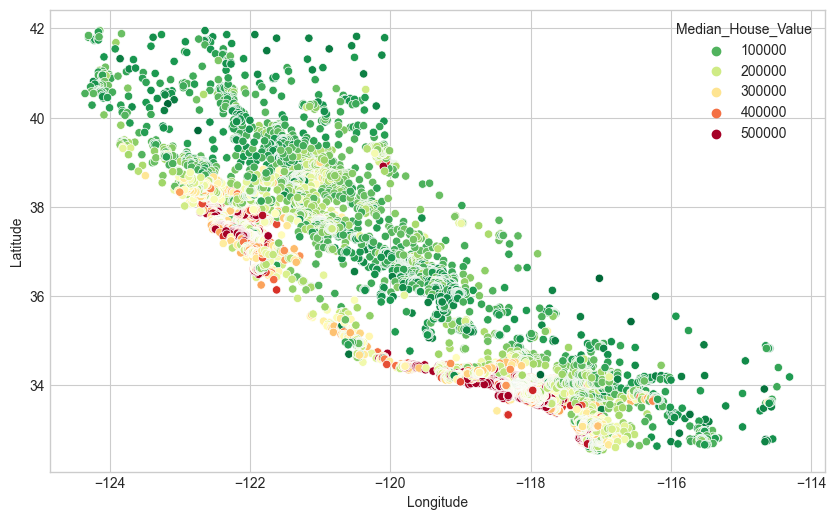

In [28]:
palette = sns.color_palette("RdYlGn_r", as_cmap=True)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data,
    x='Longitude',
    y='Latitude',
    hue='Median_House_Value',
    palette=palette,
    legend=True
)

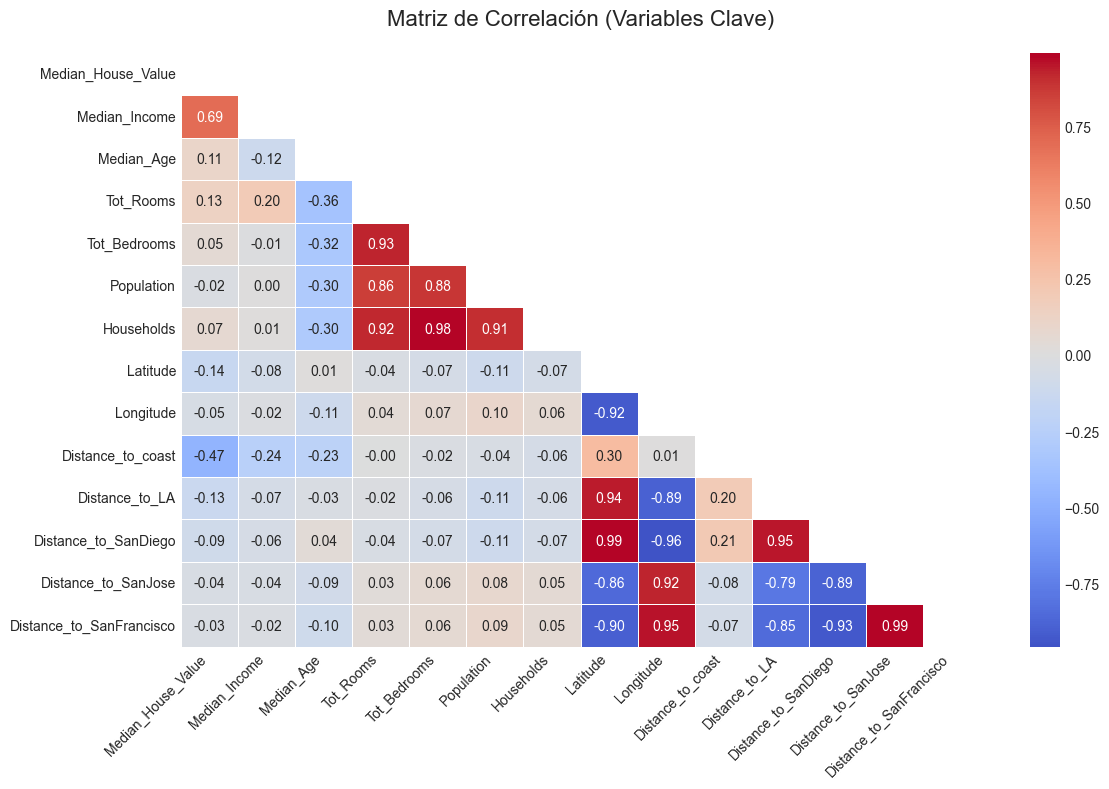

In [29]:
# Calcular matriz de correlación
corr_matrix = data.corr()

# Visualización mejorada
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', 
            center=0, fmt=".2f", linewidths=.5,
            annot_kws={"size": 10})

# Destacar correlaciones importantes
plt.title('Matriz de Correlación (Variables Clave)', pad=20, fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

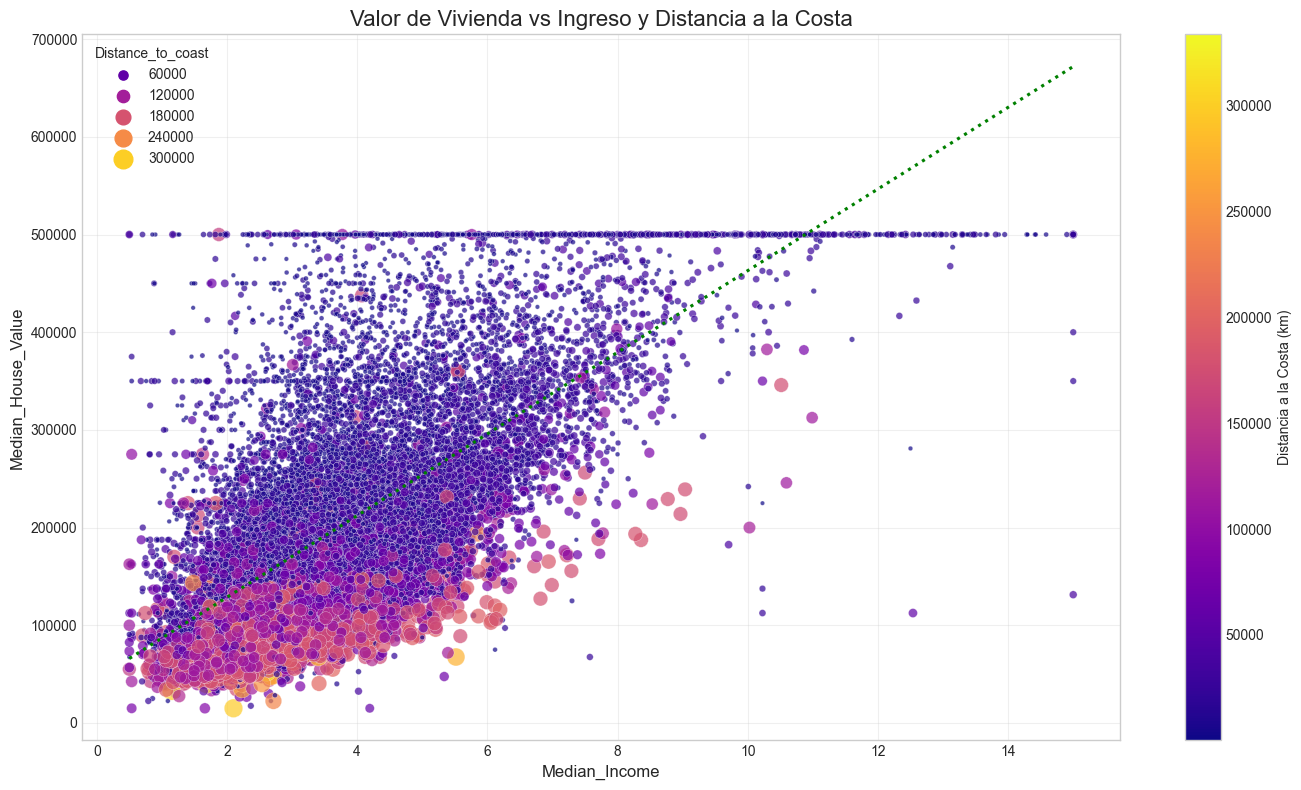

In [30]:
plt.figure(figsize=(14, 8))

# Gráfico de dispersión con dos variables explicativas
scatter = sns.scatterplot(data=data, x='Median_Income', y='Median_House_Value',
                          hue='Distance_to_coast', size='Distance_to_coast',
                          sizes=(10, 200), palette='plasma', alpha=0.7)

# Personalización
plt.title('Valor de Vivienda vs Ingreso y Distancia a la Costa', fontsize=16)
plt.xlabel('Ingreso Medio ($)', fontsize=12)
plt.ylabel('Valor Medio de Vivienda ($)', fontsize=12)

# Leyenda mejorada
norm = plt.Normalize(data['Distance_to_coast'].min(), data['Distance_to_coast'].max())
sm = plt.cm.ScalarMappable(cmap="plasma", norm=norm)
sm.set_array([])
plt.colorbar(sm, label='Distancia a la Costa (km)', ax=scatter)

# Añadir línea de tendencia para ingreso
sns.regplot(data=data, x='Median_Income', y='Median_House_Value',
            scatter=False, color='green', ci=None, line_kws={'linestyle':':'})

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

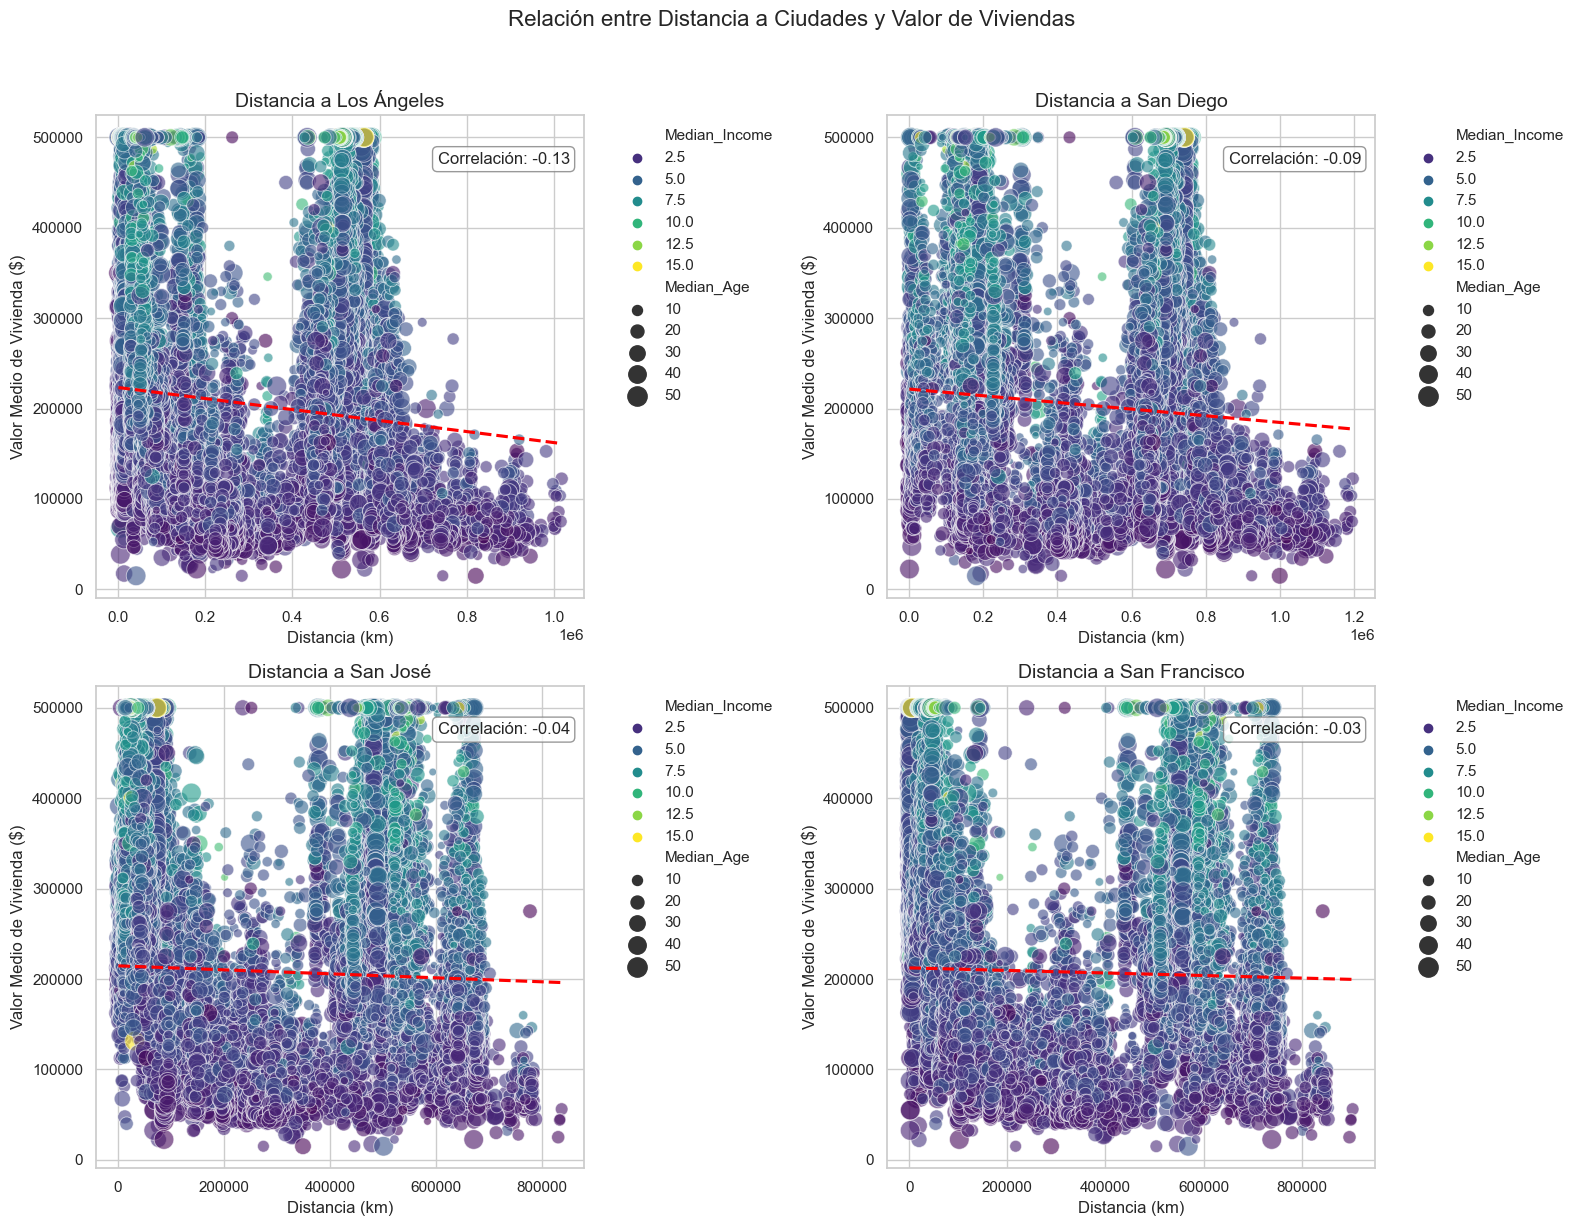

In [31]:
# Configuración de estilo
sns.set(style="whitegrid", palette="muted")

# Crear figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Relación entre Distancia a Ciudades y Valor de Viviendas', y=1.02, fontsize=16)

# Lista de ciudades y ejes correspondientes
ciudades = ['LA', 'SanDiego', 'SanJose', 'SanFrancisco']
titles = ['Los Ángeles', 'San Diego', 'San José', 'San Francisco']

for ax, ciudad, title in zip(axes.flatten(), ciudades, titles):
    sns.scatterplot(data=data, x=f'Distance_to_{ciudad}', y='Median_House_Value',
                    hue='Median_Income', size='Median_Age',
                    sizes=(20, 200), alpha=0.6, palette='viridis', ax=ax)
    
    # Añadir línea de tendencia
    sns.regplot(data=data, x=f'Distance_to_{ciudad}', y='Median_House_Value',
                scatter=False, color='red', ci=None, line_kws={'linestyle':'--'}, ax=ax)
    
    # Personalización
    ax.set_title(f'Distancia a {title}', fontsize=14)
    ax.set_xlabel('Distancia (km)', fontsize=12)
    ax.set_ylabel('Valor Medio de Vivienda ($)', fontsize=12)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Calcular y mostrar correlación
    corr = data[[f'Distance_to_{ciudad}', 'Median_House_Value']].corr().iloc[0,1]
    ax.annotate(f'Correlación: {corr:.2f}', xy=(0.7, 0.9), xycoords='axes fraction',
                bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()

In [32]:
from sklearn.preprocessing import MinMaxScaler
# Crear nuevas features
data['Rooms_per_household'] = data['Tot_Rooms'] / data['Households']
data['Bedrooms_per_room'] = data['Tot_Bedrooms'] / (data['Tot_Rooms'] + 1e-6)  # Evitar división por cero
data['Population_per_household'] = data['Population'] / data['Households']

# Normalizar variables espaciales
spatial_cols = ['Distance_to_coast', 'Distance_to_LA', 'Distance_to_SanDiego']
scaler = MinMaxScaler()
data[spatial_cols] = scaler.fit_transform(data[spatial_cols])

# Crear interacción clave
data['Income_Distance_coast'] = data['Median_Income'] * data['Distance_to_coast']

In [33]:
# Correlación con el target (Median_House_Value)
print(data[['Rooms_per_household', 'Bedrooms_per_room', 'Population_per_household', 'Median_House_Value']].corr()['Median_House_Value'])

Rooms_per_household         0.151948
Bedrooms_per_room          -0.255624
Population_per_household   -0.023737
Median_House_Value          1.000000
Name: Median_House_Value, dtype: float64


In [34]:
data.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco,Rooms_per_household,Bedrooms_per_room,Population_per_household,Income_Distance_coast
0,452600.0,8.3252,41,880,129,322,126,37.88,-122.23,0.027398,0.546362,0.614340,67432.517001,21250.213767,6.984127,0.146591,2.555556,0.228096
1,358500.0,8.3014,21,7099,1106,2401,1138,37.86,-122.22,0.030283,0.544152,0.612446,65049.908574,20880.600400,6.238137,0.155797,2.109842,0.251394
2,352100.0,7.2574,52,1467,190,496,177,37.85,-122.24,0.024390,0.544477,0.612688,64867.289833,18811.487450,8.288136,0.129516,2.802260,0.177005
3,341300.0,5.6431,52,1274,235,558,219,37.85,-122.25,0.022918,0.545050,0.613164,65287.138412,18031.047568,5.817352,0.184458,2.547945,0.129329
4,342200.0,3.8462,52,1627,280,565,259,37.85,-122.25,0.022918,0.545050,0.613164,65287.138412,18031.047568,6.281853,0.172096,2.181467,0.088148


#**3. Preprocesamiento de Datos**


---

In [35]:
# MANEJO DE NULOS (Primer paso)

imputer = SimpleImputer(strategy='median')
numeric_cols = ['Median_Income', 'Tot_Rooms', 'Tot_Bedrooms', 'Population', 'Households']
data[numeric_cols] = imputer.fit_transform(data[numeric_cols])


In [36]:

# DETECCIÓN Y TRATAMIENTO DE OUTLIERS (IQR Method)
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [37]:
# Aplicar a columnas clave (ajusta según necesidad)
outlier_columns = [
    'Median_House_Value',
    'Median_Income',
    'Tot_Rooms']

for col in outlier_columns:
    original_size = len(data)
    data = remove_outliers(data, col)
    removed = original_size - len(data)
    print(f"Outliers removidos en {col}: {removed} registros")

Outliers removidos en Median_House_Value: 1071 registros
Outliers removidos en Median_Income: 351 registros
Outliers removidos en Tot_Rooms: 1206 registros


In [38]:
# FEATURE ENGINEERING

data['Rooms_per_household'] = data['Tot_Rooms'] / data['Households']
data['Bedrooms_per_room'] = data['Tot_Bedrooms'] / (data['Tot_Rooms'] + 1e-6)
data['Population_per_household'] = data['Population'] / data['Households']


# ESCALADO (Distancias en metros)

features_to_scale = [
    'Median_Income',
    'Median_Age',
    'Tot_Rooms',
    'Tot_Bedrooms',
    'Population',
    'Households',
    'Distance_to_coast',
    'Distance_to_LA',
    'Distance_to_SanDiego',
    'Distance_to_SanJose',
    'Distance_to_SanFrancisco'
]

scaler = StandardScaler()
data[features_to_scale] = scaler.fit_transform(data[features_to_scale])

In [39]:
# VERIFICACIÓN FINAL


print("Preprocesamiento completado:")
print(f"- Registros finales: {len(data)}")
print("- Nulos restantes:", data.isnull().sum().sum())
print("- Columnas escaladas:", features_to_scale[:3], "...")  # Mostrar solo 3 para brevedad

Preprocesamiento completado:
- Registros finales: 18012
- Nulos restantes: 0
- Columnas escaladas: ['Median_Income', 'Median_Age', 'Tot_Rooms'] ...


In [40]:
data.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco,Rooms_per_household,Bedrooms_per_room,Population_per_household,Income_Distance_coast
2,352100.0,2.659661,1.858026,-0.643777,-1.090941,-1.074010,-1.105982,37.85,-122.24,-0.669821,1.125925,1.135433,-1.313395,-1.474907,8.288136,0.129516,2.802260,0.177005
3,341300.0,1.508942,1.858026,-0.813945,-0.912815,-0.986753,-0.925959,37.85,-122.25,-0.679527,1.128262,1.137389,-1.311450,-1.478046,5.817352,0.184458,2.547945,0.129329
4,342200.0,0.228060,1.858026,-0.502705,-0.734688,-0.976902,-0.754509,37.85,-122.25,-0.679527,1.128262,1.137389,-1.311450,-1.478046,6.281853,0.172096,2.181467,0.088148
5,269700.0,0.363925,1.858026,-1.126949,-0.999899,-1.190822,-1.037402,37.85,-122.25,-0.679527,1.128262,1.137389,-1.311450,-1.478046,4.761658,0.231774,2.139896,0.092516
6,299200.0,0.094690,1.858026,0.297879,0.092610,-0.232404,0.338487,37.84,-122.25,-0.697815,1.124938,1.134486,-1.315949,-1.480028,4.931907,0.192899,2.128405,0.073716


 ## 3.1 Evaluando Outliers

In [41]:
limites = {columna: 0.98 for columna in data.columns}

In [42]:
limites

{'Median_House_Value': 0.98,
 'Median_Income': 0.98,
 'Median_Age': 0.98,
 'Tot_Rooms': 0.98,
 'Tot_Bedrooms': 0.98,
 'Population': 0.98,
 'Households': 0.98,
 'Latitude': 0.98,
 'Longitude': 0.98,
 'Distance_to_coast': 0.98,
 'Distance_to_LA': 0.98,
 'Distance_to_SanDiego': 0.98,
 'Distance_to_SanJose': 0.98,
 'Distance_to_SanFrancisco': 0.98,
 'Rooms_per_household': 0.98,
 'Bedrooms_per_room': 0.98,
 'Population_per_household': 0.98,
 'Income_Distance_coast': 0.98}

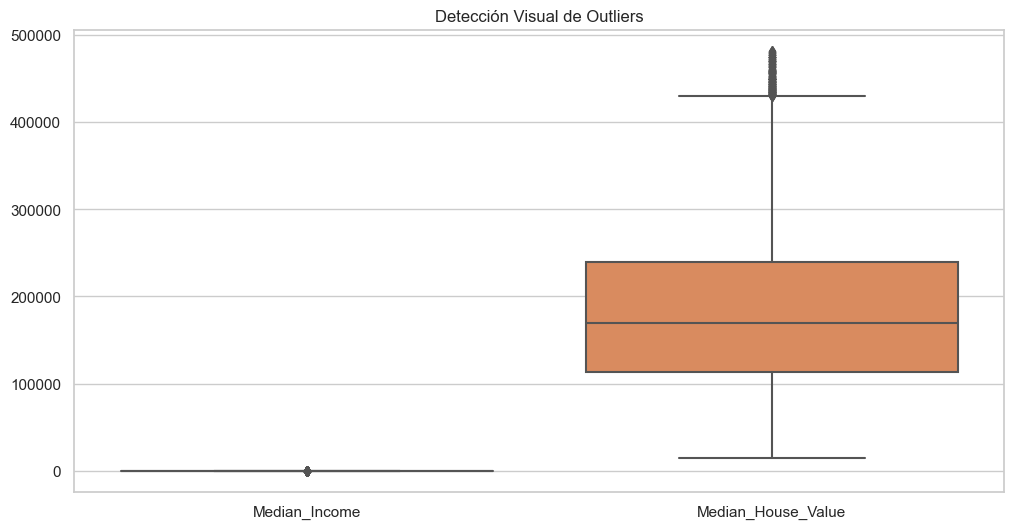

In [43]:
import seaborn as sns

# Boxplot para cada variable
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[['Median_Income', 'Median_House_Value']])
plt.title("Detección Visual de Outliers")
plt.show()

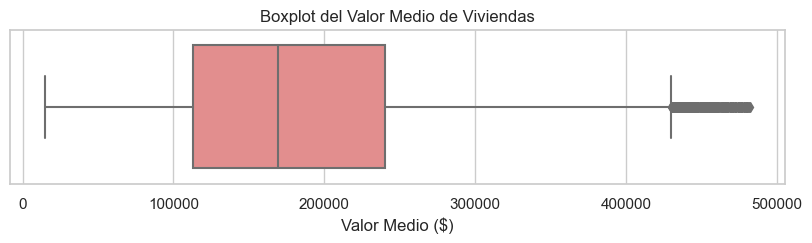

In [46]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=data['Median_House_Value'], color='lightcoral')
plt.title('Boxplot del Valor Medio de Viviendas')
plt.xlabel('Valor Medio ($)')
plt.show()

# Observamos que tenemos outliers

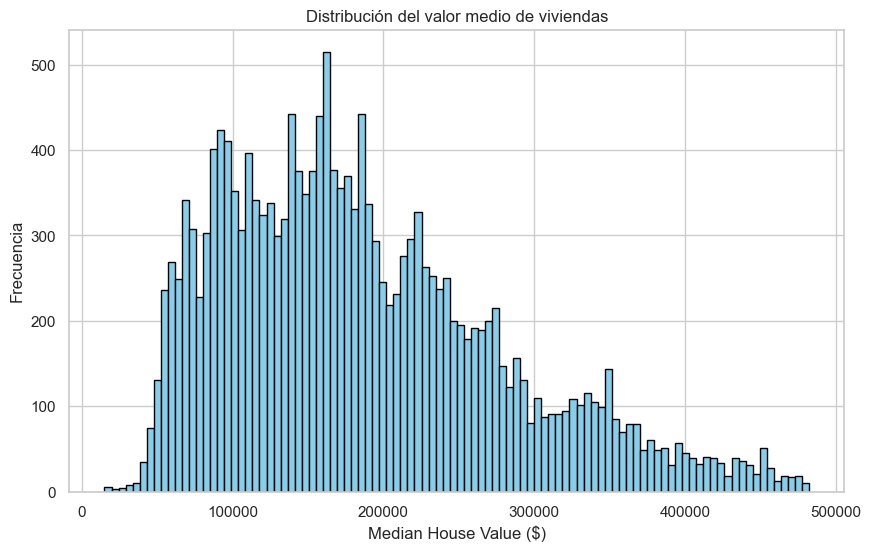

In [45]:
# En el siguiente grafico se mira que el precio de vivienda en el eje X y en el eje Y la cantidad de casas a ese precio. En 120000 y 140000 se concentra la mayor cantidad
plt.figure(figsize=(10, 6))

data["Median_House_Value"].hist(bins=100, color='skyblue', edgecolor='black')
plt.title("Distribución del valor medio de viviendas")
plt.xlabel("Median House Value ($)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

# tenemos un histograma con sesgo a la derecha 100 intervalos

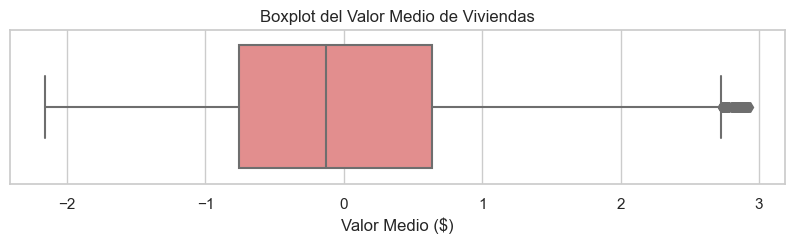

In [47]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=data['Median_Income'], color='lightcoral')
plt.title('Boxplot del Valor Medio de Viviendas')
plt.xlabel('Valor Medio ($)')
plt.show()

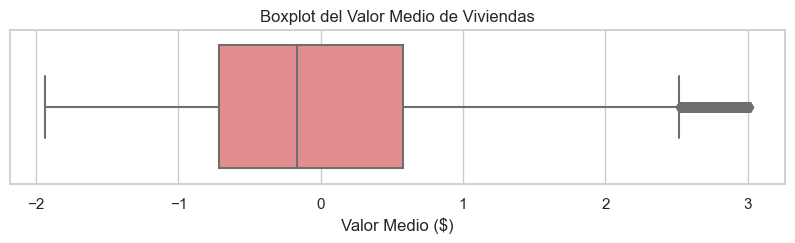

In [48]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=data['Tot_Rooms'], color='lightcoral')
plt.title('Boxplot del Valor Medio de Viviendas')
plt.xlabel('Valor Medio ($)')
plt.show()

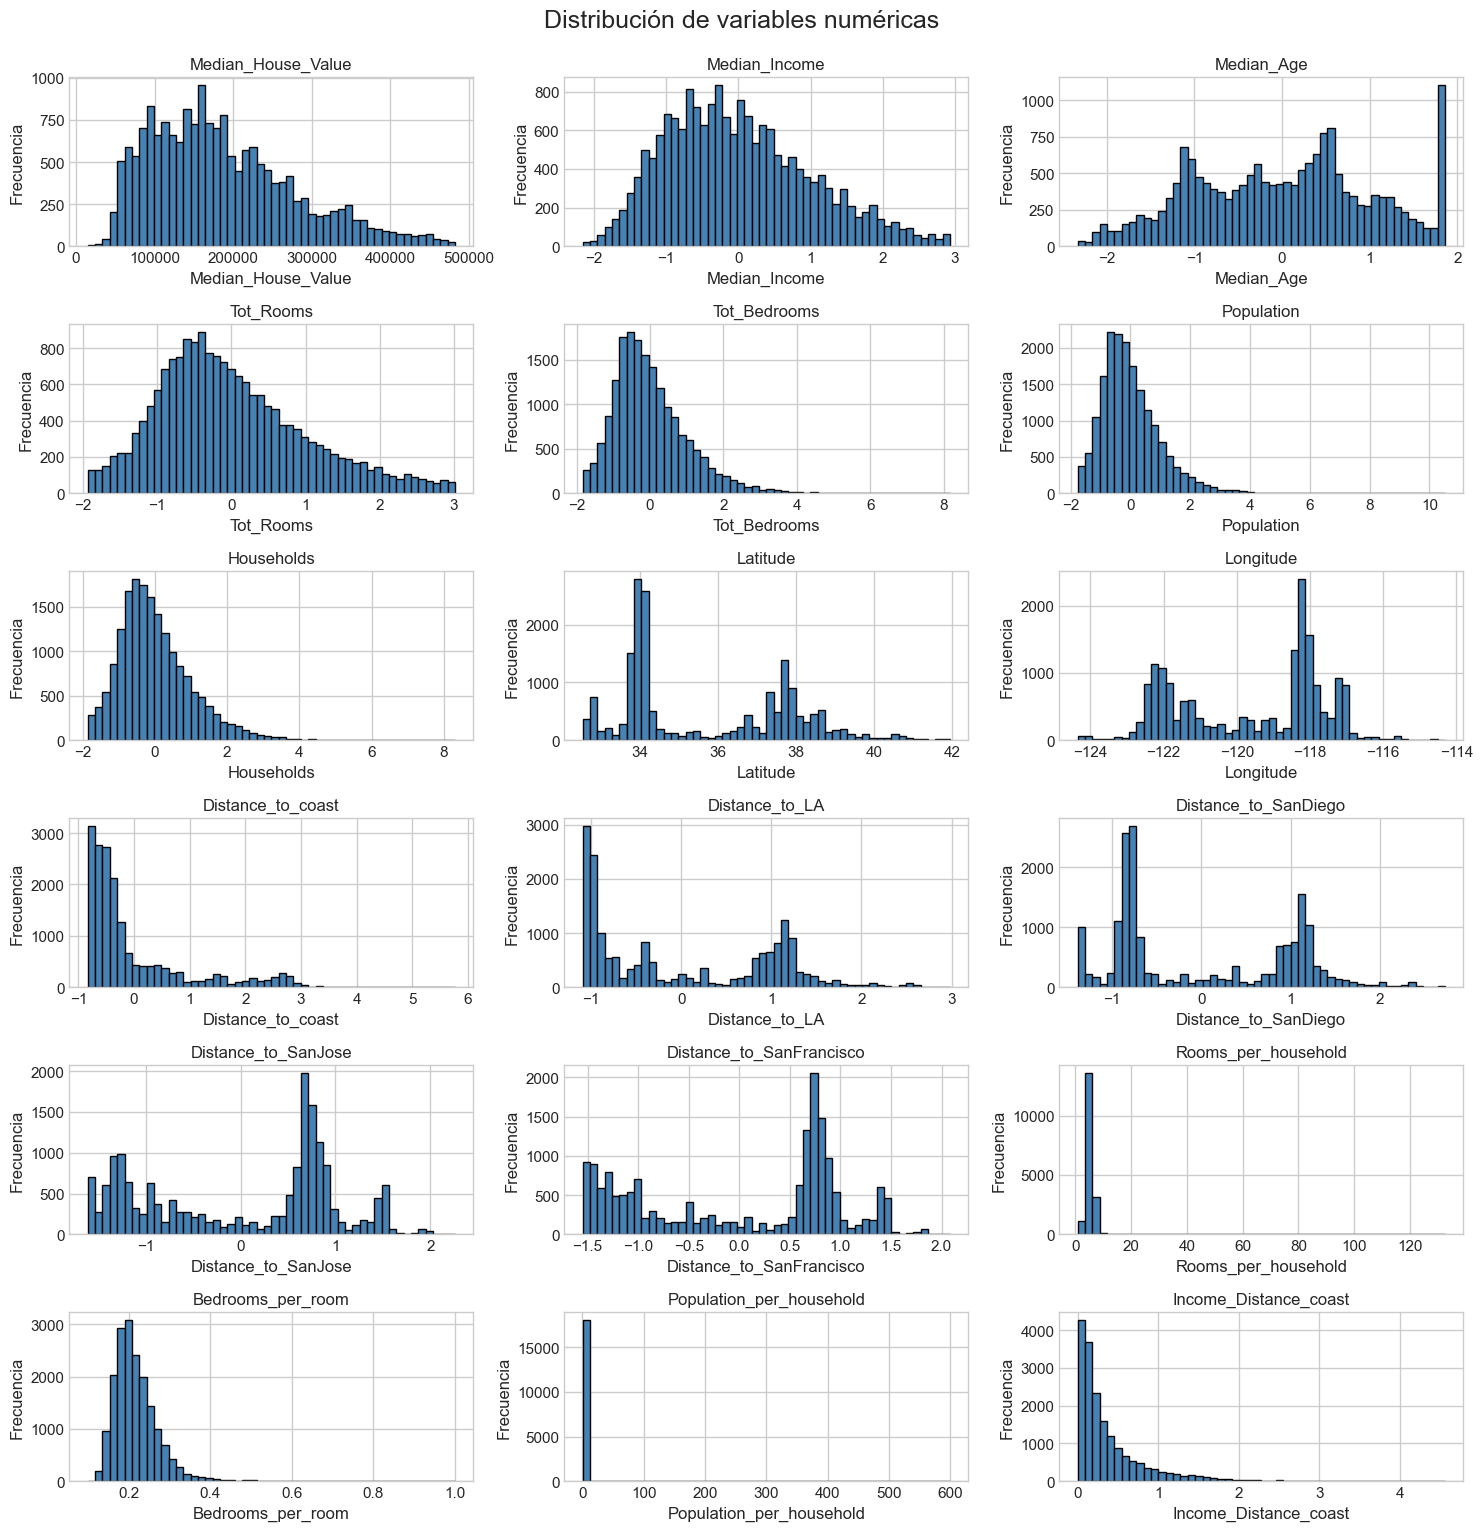

In [50]:
# Establecer estilo
plt.style.use('seaborn-whitegrid')

# Columnas numéricas (todas en tu dataset son numéricas)
columnas = data.select_dtypes(include='number').columns

# Crear los histogramas
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(columnas):
    data[col].hist(bins=50, ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

# Ajustar espacios
plt.tight_layout()
plt.suptitle("Distribución de variables numéricas", fontsize=18, y=1.02)
plt.show()

## 3.2 Truncando la variable

In [51]:
vars = data.columns
vars

Index(['Median_House_Value', 'Median_Income', 'Median_Age', 'Tot_Rooms',
       'Tot_Bedrooms', 'Population', 'Households', 'Latitude', 'Longitude',
       'Distance_to_coast', 'Distance_to_LA', 'Distance_to_SanDiego',
       'Distance_to_SanJose', 'Distance_to_SanFrancisco',
       'Rooms_per_household', 'Bedrooms_per_room', 'Population_per_household',
       'Income_Distance_coast'],
      dtype='object')

#**4. Construcción de Modelos**


---

In [52]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import lightgbm as lgb

In [53]:
# Dividir datos
X = data.drop('Median_House_Value', axis=1)
y = data['Median_House_Value']

In [54]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 4.1 Ramdon Forest

In [98]:
# modelo
model_rf = RandomForestRegressor(
    n_estimators=100, 
    random_state=42)
# Entrenamiento
model_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [99]:
# Predicción
y_pred_rf = model_rf.predict(X_test)

In [100]:
# Métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Resultados:")
print(f"- MAE: $ {mae:,.2f}")
print(f"- R²: {r2:.4f}")
print(f"- RMSE: $ {rmse:,.2f}")

Resultados:
- MAE: $ 26,178.00
- R²: 0.8104
- RMSE: $ 39,941.85


## 4.2 xgboost

In [75]:
# Configuración para evitar el error de representación
import warnings
from xgboost import XGBRegressor
from sklearn.exceptions import SkipTestWarning
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
warnings.filterwarnings("ignore", category=SkipTestWarning)

In [60]:
model = XGBRegressor(
    n_estimators=100,
    random_state=42,
    enable_categorical=False  # Importante para datos no categóricos
)

# Entrenar sin mostrar output intermedio
model.fit(X_train, y_train, verbose=0)

# Predicción y evaluación
y_pred = model.predict(X_test)

# Métricas

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Resultados:")
print(f"- MAE: $ {mae:,.2f}")
print(f"- R²: {r2:.4f}")
print(f"- RMSE: $ {rmse:,.2f}")

Resultados:
- MAE: $ 27,144.64
- R²: 0.7990
- RMSE: $ 41,125.35


In [61]:
from sklearn.model_selection import GridSearchCV

In [119]:
# 1. Definir el espacio de búsqueda de hiperparámetros

params = {
    'n_estimators': [100, 200],      # Número de árboles
    'max_depth': [3, 6],             # Profundidad máxima de cada árbol
    'learning_rate': [0.01, 0.1],    # Tasa de aprendizaje
    'subsample': [0.8, 1.0],         
    'colsample_bytree': [0.8, 1.0]   
}

# 2. Configurar GridSearchCV
grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),  # Paraleliza en todos los cores
    param_grid=params,
    cv=3,                           # 3-fold cross-validation
    scoring='neg_mean_squared_error',  # Métrica a optimizar (RMSE)
    verbose=2                       # Muestra progreso
)

# 3. Ejecutar la búsqueda
grid.fit(X_train, y_train)

# 4. Obtener el mejor modelo
best_model = grid.best_estimator_
print("\n🔥 Mejores hiperparámetros encontrados:")
print(grid.best_params_)

# 5. Evaluar en el conjunto de prueba
y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n Rendimiento del mejor modelo:")
print(f"- RMSE: {rmse:.2f}")
print(f"- R²: {r2:.4f}")

Fitting 3 folds for each of 32 candidates, totalling 96 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.0s
[CV] END co

In [63]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.0s
[CV] END co

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
            

In [95]:
# Hacer predicciones con el mejor modelo
model_xgb = grid.best_estimator_
y_pred_xgb = model_xgb.predict(X_test) 

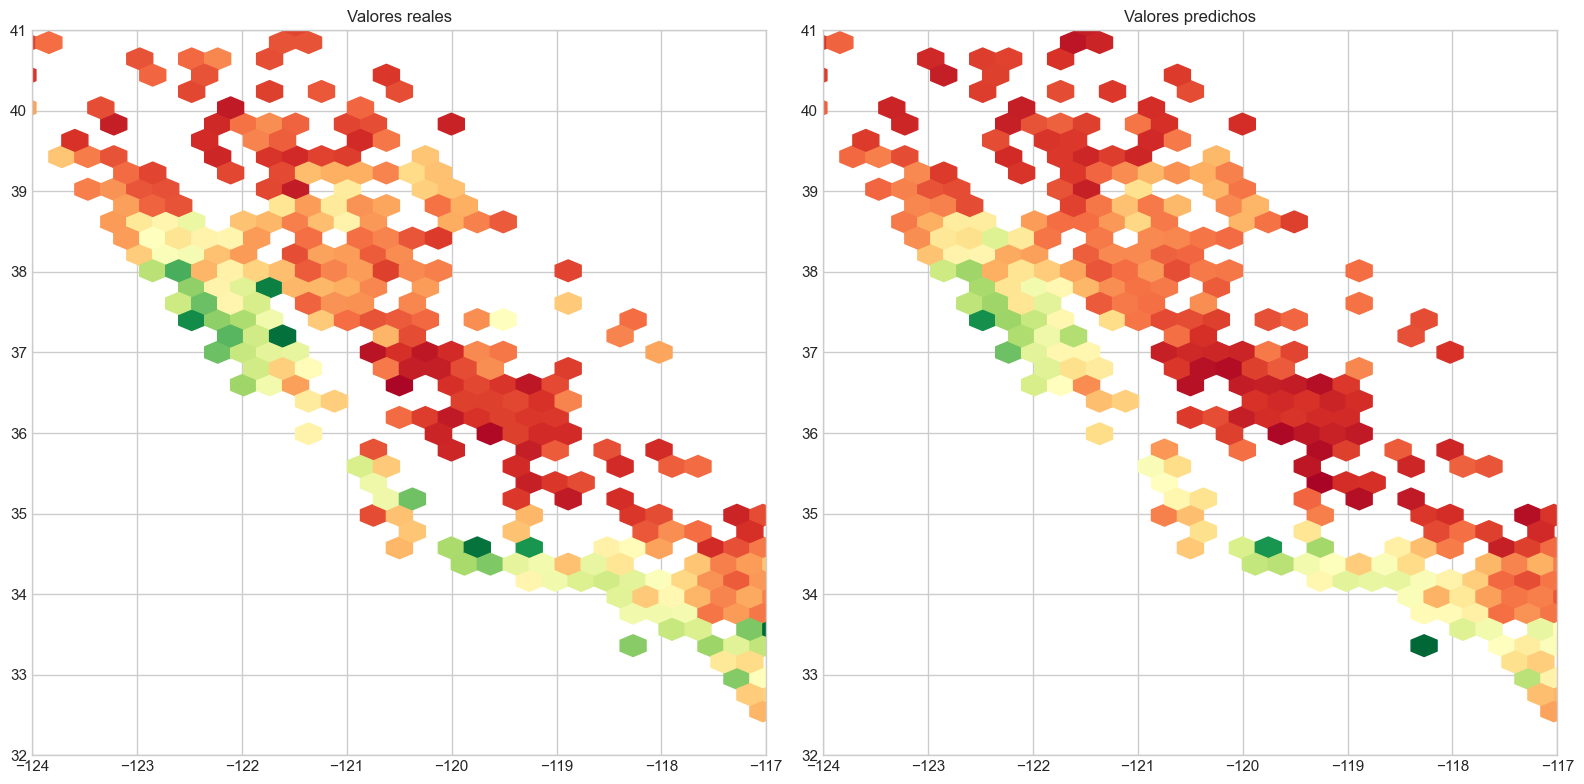

In [ ]:
X_test_plot = X_test.copy()
X_test_plot['Actual'] = y_test
X_test_plot['Predicted'] = y_pred
X_test_plot['Latitude'] = X_test_plot['Latitude']  # Asegúrate de que están
X_test_plot['Longitude'] = X_test_plot['Longitude']

# Graficar tipo hexbin (como en tu imagen)
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Hexbin - Valores reales
axs[0].hexbin(
    X_test_plot['Longitude'],
    X_test_plot['Latitude'],
    C=X_test_plot['Actual'],
    gridsize=40,
    cmap='RdYlGn',
    reduce_C_function=np.mean
)
axs[0].set_title("Valores reales")
axs[0].set_xlim([-124, -117])
axs[0].set_ylim([32, 41])

# Hexbin - Valores predichos
axs[1].hexbin(
    X_test_plot['Longitude'],
    X_test_plot['Latitude'],
    C=X_test_plot['Predicted'],
    gridsize=40,
    cmap='RdYlGn',
    reduce_C_function=np.mean
)
axs[1].set_title("Valores predichos")
axs[1].set_xlim([-124, -117])
axs[1].set_ylim([32, 41])

plt.tight_layout()
plt.show()

## 4.3 lightgbm

In [68]:
import lightgbm as lgb

In [70]:
model_lgb = lgb.LGBMRegressor(
    boosting_type='gbdt',          # Algoritmo de boosting tradicional
    num_leaves=31,                # Hojas máximas (controla complejidad)
    max_depth=-1,                 # Profundidad ilimitada (se controla con num_leaves)
    learning_rate=0.05,           # Tasa de aprendizaje más conservadora
    n_estimators=150,             # Más iteraciones que en XGBoost (converge más rápido)
    reg_alpha=0.1,                # Regularización L1
    reg_lambda=0.1,               # Regularización L2
    random_state=42,
    force_row_wise=True,          # Optimización para datasets no muy grandes
    feature_fraction=0.9,         # Porcentaje de features por iteración (previene overfitting)
    min_data_in_leaf=20           # Mínimo de datos por hoja (ideal para datos espaciales)
)


In [71]:
# Entrenamiento con early stopping
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='mae',
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=True),
        lgb.log_evaluation(period=0)  # Sin output intermedio
    ])


[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[150]	valid_0's l1: 27814.1	valid_0's l2: 1.7321e+09


LGBMRegressor(feature_fraction=0.9, force_row_wise=True, learning_rate=0.05,
              min_data_in_leaf=20, n_estimators=150, random_state=42,
              reg_alpha=0.1, reg_lambda=0.1)

In [72]:
# Predicción
y_pred_lgb = model_lgb.predict(X_test)

Resultados LightGBM:
- MAE: $ 27,814.14 (reducción de -2.47% vs XGBoost)
- R²: 0.7941 (mejoría de -1.63% vs XGBoost)
- RMSE: $ 41,618.49 (reducción de -4.20% vs XGBoost)


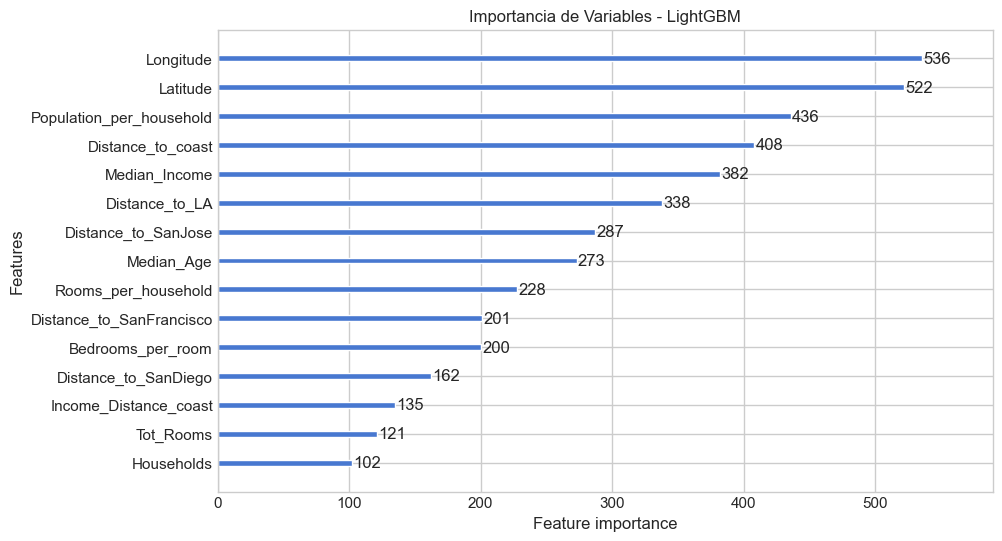

In [74]:
# Métricas mejoradas
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))


print("Resultados LightGBM:")
print(f"- MAE: $ {mae_lgb:,.2f} (reducción de {((mae - mae_lgb)/mae)*100:.2f}% vs XGBoost)")
print(f"- R²: {r2_lgb:.4f} (mejoría de {(r2_lgb - r2)*100:.2f}% vs XGBoost)")
print(f"- RMSE: $ {rmse_lgb:,.2f} (reducción de {((rmse - rmse_lgb)/rmse)*100:.2f}% vs XGBoost)")


# Importancia de variables
lgb.plot_importance(model_lgb, figsize=(10, 6), max_num_features=15)
plt.title("Importancia de Variables - LightGBM")
plt.show()

In [77]:
param_grid = {
    'num_leaves': [20, 31, 50],         # Controla complejidad del árbol
    'learning_rate': [0.01, 0.05],      # Tasa de aprendizaje
    'n_estimators': [100, 200],         # Número de árboles
    'min_data_in_leaf': [10, 20, 30]    # Ideal para datos geoespaciales
}

In [80]:
lgb_model = lgb.LGBMRegressor(
    objective='regression',  # Puedes omitirlo (es el default)
    random_state=42
)

In [81]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,  # Validación cruzada de 3 folds
    scoring={
        'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
        'R2': 'r2',
        'RMSE': make_scorer(lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred))), 
    },
    refit='MAE',  # Optimizar para MAE
    n_jobs=-1,  # Usar todos los cores
    verbose=1
)

In [82]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20


GridSearchCV(cv=3,
             estimator=LGBMRegressor(objective='regression', random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05],
                         'min_data_in_leaf': [10, 20, 30],
                         'n_estimators': [100, 200],
                         'num_leaves': [20, 31, 50]},
             refit='MAE',
             scoring={'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
                      'R2': 'r2', 'RMSE': make_scorer(<lambda>)},
             verbose=1)

In [ ]:
# Hacer predicciones con el mejor modelo
lgb_model = grid_search.best_estimator_
y_pred_optimized_lgb = lgb_model.predict(X_test)

In [122]:
print("\nResultados en Test:")
print(f"- MAE: ${mean_absolute_error(y_test, y_pred_optimized_lgb):,.2f}")
print(f"- R²: {r2_score(y_test, y_pred_optimized_lgb):.4f}")
print(f"- RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_optimized_lgb)):,.2f}")


Resultados en Test:
- MAE: $26,655.98
- R²: 0.8060
- RMSE: $40,399.71


## 4.4 SVR

In [86]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [ ]:
# 1. Crear pipeline 
model_svr = make_pipeline(
    StandardScaler(),       # SVR es sensible a la escala
    SVR(
        kernel='rbf',       # Kernel radial para no-linealidad
        C=1.0,              # Parámetro de regularización
        epsilon=0.1,        # Margen de error permitido
        gamma='scale'       # Influencia de cada punto
    )
)

In [92]:
# 2. Entrenar
model_svr.fit(X_train, y_train)

# 3. Evaluar
y_pred_svr = model_svr.predict(X_test)

# Métricas
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print("\n Resultados en SVR:")
print(f"- MAE: ${mae_svr:,.2f}")
print(f"- R²: {r2_svr:.4f}")
print(f"- RMSE: ${rmse_svr:,.2f}")



 Resultados en SVR:
- MAE: $71,899.63
- R²: -0.0219
- RMSE: $92,717.53


**5. Evaluación y Selección del Modelo**


---

In [93]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

In [123]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Función para calcular MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Predicciones para cada modelo
y_pred_xgb = model_xgb.predict(X_test)  # XGBoost
y_pred_optimized_lgb = lgb_model.predict(X_test)  # LightGBM
y_pred_svr = model_svr.predict(X_test)  # SVR
y_pred_rf = model_rf.predict(X_test)    # Random Forest

# Cálculo de métricas para cada modelo
def calculate_metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R²': r2_score(y_true, y_pred),
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred)
    }

metrics_xgb = calculate_metrics(y_test, y_pred_xgb)
metrics_lgb = calculate_metrics(y_test, y_pred_optimized_lgb)
metrics_svr = calculate_metrics(y_test, y_pred_svr)
metrics_rf = calculate_metrics(y_test, y_pred_rf)

# Crear tabla comparativa
import pandas as pd

comparison = pd.DataFrame({
    'XGBoost': metrics_xgb,
    'LightGBM': metrics_lgb,
    'SVR': metrics_svr,
    'Random Forest': metrics_rf
}).T


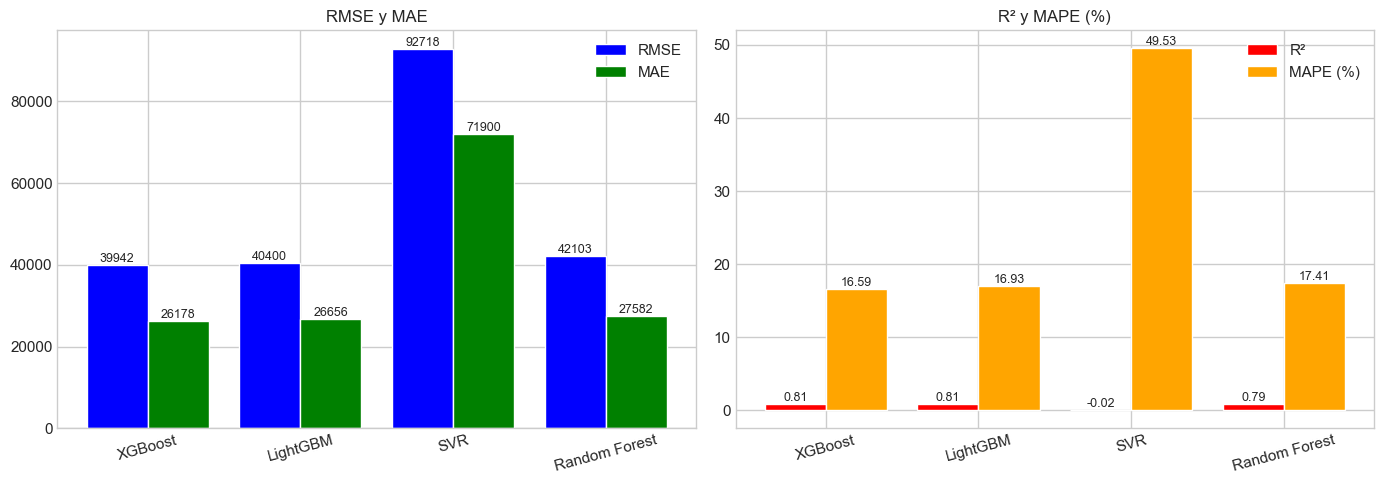

In [124]:
import matplotlib.pyplot as plt

# Copia y convierte a valores numéricos
comparison_plot = comparison.copy()
for col in ['RMSE', 'MAE']:
    comparison_plot[col] = comparison_plot[col].replace('[\$,]', '', regex=True).astype(float)

# Datos base
modelos = comparison_plot.index.tolist()
x = np.arange(len(modelos))
width = 0.4

# Crear figura
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: RMSE y MAE
rmse = comparison_plot['RMSE']
mae = comparison_plot['MAE']
b1 = axs[0].bar(x - 0.2, rmse, width=width, label='RMSE', color='blue')
b2 = axs[0].bar(x + 0.2, mae, width=width, label='MAE', color='green')
axs[0].set_xticks(x)
axs[0].set_xticklabels(modelos, rotation=15)
axs[0].set_title('RMSE y MAE')
axs[0].legend()

# Agregar valores encima
for bar in b1 + b2:
    axs[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.0f}', 
                ha='center', va='bottom', fontsize=9)

# Gráfico 2: R² y MAPE
r2 = comparison_plot['R²']
mape = comparison_plot['MAPE (%)']
b3 = axs[1].bar(x - 0.2, r2, width=width, label='R²', color='red')
b4 = axs[1].bar(x + 0.2, mape, width=width, label='MAPE (%)', color='orange')
axs[1].set_xticks(x)
axs[1].set_xticklabels(modelos, rotation=15)
axs[1].set_title('R² y MAPE (%)')
axs[1].legend()

# Agregar valores encima
for bar in b3 + b4:
    axs[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.2f}', 
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


# Conclusiones XGBoost es el mejor modelo de estudio

##  R² = (0.81): Eso explica mejor la variabilidad de los datos.
##  RMSE bajo = más bajo indica que el modelo es más preciso.